## Fraud Detection Part 2: Real Transactions at Scale (IEEE-CIS)

Part 1 (`01_synthetic_investigation.ipynb`) concluded that when labels exist, IsolationForest should not be the primary fraud model: it flags *rare* transactions rather than *risky* ones. This notebook applies that conclusion to **real e-commerce transactions** from the IEEE-CIS Fraud Detection dataset (Vesta Corporation, via Kaggle).

**Approach**
- Memory-efficient loading of 590k transactions × 434 features
- Time-based train / validation / test split, so the model is scored on future transactions
- LightGBM as the primary model, with the IsolationForest score as an extra feature
- Average Precision as the primary metric (the data is imbalanced)
- Alert threshold set by cost: fraud value caught vs alerts per 1,000 transactions
- Drift monitoring with PSI across time periods

**Data:** `train_transaction.csv` and `train_identity.csv` from kaggle.com/competitions/ieee-fraud-detection, placed in `data/`. The competition test set has no public labels, so only the training files are used.

### Business question

A fraud operations team can only review a limited number of transactions each day. Every missed fraud is lost money, and every alert costs analyst time and can annoy a genuine customer.

> **Which transactions should the team review to minimise fraud losses plus review costs, and how will it know when the model has stopped working?**

**Decisions this project supports**
1. **Where to set the alert threshold**, given what an analyst review costs.
2. **How many analysts are needed**, from the expected alerts per day.
3. **When to retrain**, using drift signals that work before fraud labels arrive.

**How success is measured**
| Measure | Why it matters to the business |
|---|---|
| Fraud value caught ($ and % of losses) | Money protected |
| Net saving vs no model (fraud prevented − review cost) | Return on the model and the review team |
| Alerts per day and per 1,000 transactions | Analyst workload and staffing |
| Alert precision | Analyst efficiency and customer friction |
| Score drift (PSI) | Early warning that the model needs attention |

Model metrics (Average Precision) are used to **choose** the model. The business measures above are used to **judge** it. Results are summarised in section 12, and shown interactively in the Streamlit dashboard (`dashboard/app.py`).


### Setup

In [1]:
import gc
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path('data')
TRANSACTION_CSV = DATA_DIR / 'train_transaction.csv'
IDENTITY_CSV = DATA_DIR / 'train_identity.csv'
PARQUET = DATA_DIR / 'ieee_cis_train.parquet'
MEMORY_REPORT = DATA_DIR / 'memory_report.json'

RANDOM_STATE = 42


def mem_gb(d):
    # deep=True counts the real size of string/object columns, not just pointers
    return d.memory_usage(deep = True).sum() / 1e9

### 1. Loading the data efficiently

Loaded naively, pandas stores every numeric column as 64-bit and every text column as Python strings. The plan:

1. **Measure the naive load** once, as a baseline.
2. **Infer compact dtypes** from a sample: `float32` for numeric features, `category` for text columns, and the smallest integer type for IDs, time and the label.
3. **Load with those dtypes** and join the identity table onto the transactions.
4. **Cache to Parquet**, a columnar format that keeps the dtypes and reloads much faster than CSV.

Steps 1 to 3 only run the first time. Later runs load the Parquet file directly, and the first run's memory measurements are saved so they're always shown.

In [2]:
def infer_dtypes(path, sample_rows = 100_000):
    # Infer compact dtypes from a sample of rows instead of loading everything as 64-bit
    sample = pd.read_csv(path, nrows = sample_rows)
    dtypes = {}
    for col in sample.columns:
        if col in ('TransactionID', 'TransactionDT'):
            dtypes[col] = 'int32'      # max values (~3.7M, ~16M) fit comfortably in int32
        elif col == 'isFraud':
            dtypes[col] = 'int8'
        elif pd.api.types.is_numeric_dtype(sample[col]):
            dtypes[col] = 'float32'    # float32 also holds NaN, which most features contain
        else:
            dtypes[col] = 'category'   # text columns repeat a small set of values
    return dtypes


def load_optimised():
    transactions = pd.read_csv(TRANSACTION_CSV, dtype = infer_dtypes(TRANSACTION_CSV))
    identity = pd.read_csv(IDENTITY_CSV, dtype = infer_dtypes(IDENTITY_CSV))
    # Left join: only some transactions have identity information
    return transactions.merge(identity, on = 'TransactionID', how = 'left')

In [3]:
if PARQUET.exists() and MEMORY_REPORT.exists():
    memory_report = json.loads(MEMORY_REPORT.read_text())
    t0 = time.time()
    df = pd.read_parquet(PARQUET)
    memory_report['load time from Parquet (s)'] = time.time() - t0
else:
    memory_report = {}
    # 1. Naive baseline: default dtypes
    t0 = time.time()
    naive = pd.read_csv(TRANSACTION_CSV).merge(pd.read_csv(IDENTITY_CSV), on = 'TransactionID', how = 'left')
    memory_report['naive memory (GB)'] = mem_gb(naive)
    memory_report['naive load time (s)'] = time.time() - t0
    del naive
    gc.collect()

    # 2-3. Optimised load
    t0 = time.time()
    df = load_optimised()
    memory_report['optimised load time (s)'] = time.time() - t0

    # 4. Cache to Parquet
    df.to_parquet(PARQUET, index = False)
    t0 = time.time()
    df = pd.read_parquet(PARQUET)
    memory_report['load time from Parquet (s)'] = time.time() - t0
    memory_report['Parquet file size (GB)'] = PARQUET.stat().st_size / 1e9
    memory_report['optimised memory (GB)'] = mem_gb(df)
    memory_report['memory reduction (%)'] = 100 * (1 - memory_report['optimised memory (GB)'] / memory_report['naive memory (GB)'])
    MEMORY_REPORT.write_text(json.dumps(memory_report, indent = 2))

pd.Series(memory_report).round(2)

naive memory (GB)              2.08
naive load time (s)           31.40
optimised load time (s)       33.29
load time from Parquet (s)     5.16
Parquet file size (GB)         0.08
optimised memory (GB)          0.97
memory reduction (%)          53.36
dtype: float64

### 2. Sanity checks

In [4]:
# Expected from the Kaggle documentation: 590,540 transactions, 394 transaction + 41 identity columns (434 after the join)
checks = {
    'rows': (len(df), 590_540),
    'columns': (df.shape[1], 434),
    'unique TransactionID': (df['TransactionID'].nunique(), 590_540),
}
for name, (actual, expected) in checks.items():
    print(f"{name:22s} {actual:>10,}  expected {expected:>10,}  {'OK' if actual == expected else 'CHECK'}")

print(f"\nFraud rate: {df['isFraud'].mean():.4f}")
print(f"Transactions with identity data: {df['DeviceType'].notna().mean():.1%}")
df['TransactionDT'].describe()

rows                      590,540  expected    590,540  OK
columns                       434  expected        434  OK
unique TransactionID      590,540  expected    590,540  OK

Fraud rate: 0.0350
Transactions with identity data: 23.8%


count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

### 3. Time features

`TransactionDT` is a time offset in seconds from an undisclosed reference point, not a real timestamp. We derive:
- `day`: days since the reference point, used for the time-based split
- `period`: 30-day blocks, used for drift monitoring and per-period performance. The last few days are folded into the final block so there is no tiny stub period
- `hour`: hour of day, used as a model feature (assuming the reference point is at midnight)

Raw `TransactionDT` is **not** used as a feature: the test period's values are all larger than anything seen in training, so it can't generalise.

In [5]:
df['day'] = (df['TransactionDT'] // 86_400).astype('int16')
last_full_period = (df['day'].max() + 1) // 30 - 1
df['period'] = (df['day'] // 30).clip(upper = last_full_period).astype('int8')
df['hour'] = ((df['TransactionDT'] // 3_600) % 24).astype('int8')

df.groupby('period').agg(
    transactions = ('isFraud', 'size'),
    fraud_rate = ('isFraud', 'mean'),
    first_day = ('day', 'min'),
    last_day = ('day', 'max'),
)

,transactions,fraud_rate,first_day,last_day
period,,,,
0,130968,0.024762,1,29
1,89838,0.040373,30,59
2,91768,0.040319,60,89
3,98027,0.039265,90,119
4,85303,0.034723,120,149
5,94636,0.034680,150,182


### 4. Exploratory analysis

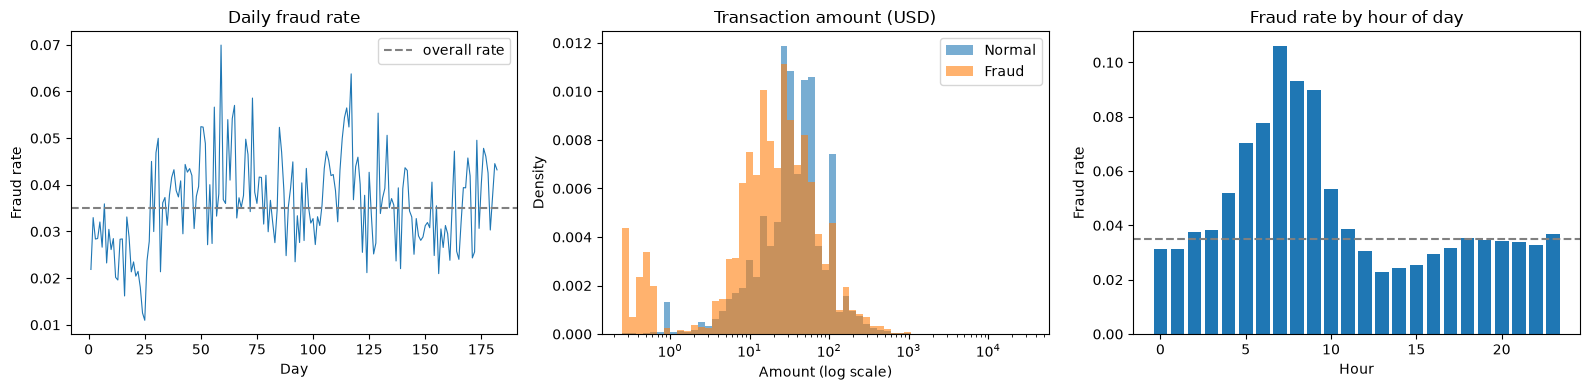

In [6]:
fig, axes = plt.subplots(1, 3, figsize = (16, 4))

# Fraud rate over time: is the label stable across the 6 months?
daily = df.groupby('day')['isFraud'].mean()
axes[0].plot(daily.index, daily.values, linewidth = 0.8)
axes[0].axhline(df['isFraud'].mean(), color = 'grey', linestyle = '--', label = 'overall rate')
axes[0].set(title = 'Daily fraud rate', xlabel = 'Day', ylabel = 'Fraud rate')
axes[0].legend()

# Amount distribution (log scale): fraud vs normal
bins = np.logspace(np.log10(max(df['TransactionAmt'].min(), 0.1)), np.log10(df['TransactionAmt'].max()), 60)
axes[1].hist(df.loc[df['isFraud'] == 0, 'TransactionAmt'], bins = bins, density = True, alpha = 0.6, label = 'Normal')
axes[1].hist(df.loc[df['isFraud'] == 1, 'TransactionAmt'], bins = bins, density = True, alpha = 0.6, label = 'Fraud')
axes[1].set(xscale = 'log', title = 'Transaction amount (USD)', xlabel = 'Amount (log scale)', ylabel = 'Density')
axes[1].legend()

# Fraud rate by hour of day
hourly = df.groupby('hour')['isFraud'].mean()
axes[2].bar(hourly.index, hourly.values)
axes[2].axhline(df['isFraud'].mean(), color = 'grey', linestyle = '--')
axes[2].set(title = 'Fraud rate by hour of day', xlabel = 'Hour', ylabel = 'Fraud rate')

plt.tight_layout()
plt.show()

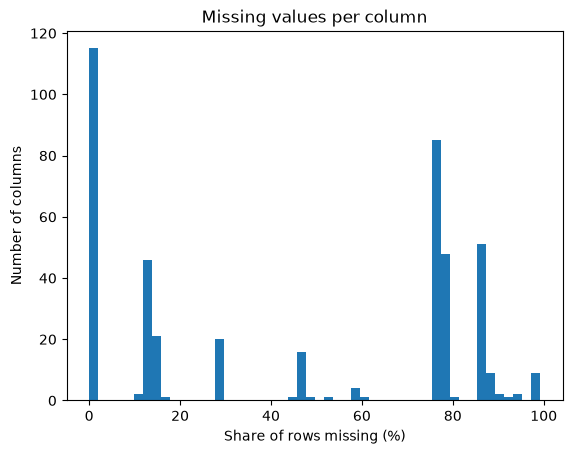

Columns > 50% missing: 214
Columns > 90% missing: 12


In [7]:
# Missing values: how many columns are mostly empty?
missing = df.isna().mean().sort_values(ascending = False)

plt.hist(missing * 100, bins = 50)
plt.xlabel('Share of rows missing (%)')
plt.ylabel('Number of columns')
plt.title('Missing values per column')
plt.show()

print(f"Columns > 50% missing: {(missing > 0.5).sum()}")
print(f"Columns > 90% missing: {(missing > 0.9).sum()}")

**Reading the EDA.**
- **The fraud rate drifts.** It is about 2.5% in the first 30 days and 3.5–4% afterwards (see the period table in section 3). A model trained on early data sees a different fraud mix from the one it is scored on, which is why section 11 monitors drift.
- **Micro-transactions are high-risk.** Only 152 transactions are under $1, but 14.5% of them are fraud, about 4x the base rate. This is consistent with **card testing**: fraudsters making tiny purchases to check that stolen card details work before using them for larger amounts. It's a small volume, so it is a signal for the model rather than a rule on its own.
- **Fraud is concentrated at certain hours**, peaking at about 10% around hours 5–9. `TransactionDT`'s reference point is not known to be midnight, so these are *relative* hours, not clock times. The pattern is still usable as a feature.
- **The data is very sparse.** 214 of 434 columns are more than 50% missing, and only 23.8% of transactions have identity data. Missingness itself is informative (e.g. whether device information was captured), so we keep most columns and let LightGBM handle missing values natively, rather than imputing.

### 5. Time-based split

Fraud models are trained on the past and scored on future transactions, so a random split would leak information from the future into training and overstate performance. Split by `day`:
- **Train:** the earliest ~4 months
- **Validation:** the next ~1 month, for tuning and choosing the threshold
- **Test:** the final ~1 month, used **once** for the final evaluation

In [8]:
last_day = df['day'].max()
valid_start = last_day - 60
test_start = last_day - 30

train = df[df['day'] < valid_start]
valid = df[(df['day'] >= valid_start) & (df['day'] < test_start)]
test = df[df['day'] >= test_start]

pd.DataFrame({
    split: {
        'transactions': len(d),
        'frauds': int(d['isFraud'].sum()),
        'fraud rate': d['isFraud'].mean(),
        'days': f"{d['day'].min()}-{d['day'].max()}",
    }
    for split, d in [('train', train), ('validation', valid), ('test', test)]
}).T

,transactions,frauds,fraud rate,days
train,417559,14721,0.035255,1-121
validation,83655,2828,0.033806,122-151
test,89326,3114,0.034861,152-182


### 6. Feature engineering and selection

**Engineered features.** A small set of features that a fraud analyst would recognise:
- `amt_cents`: the decimal part of the amount. Unusual cent values can indicate currency conversion or scripted test transactions.
- `email_match`: whether the purchaser and recipient email domains match.
- **Per-card history**, using a card key built from `card1`, `card2`, `addr1` and `card6`. Rows with no `card1` or `addr1` get no key, so they aren't lumped together as one "card":
  - `card_txn_count_30d`: the card's transactions in the previous 30 days
  - `card_amt_mean_30d`: the card's average amount over the previous 30 days
  - `amt_vs_card_mean_30d`: this amount relative to that 30-day average (sudden large purchases)
  - `secs_since_card_prev`: time since the card's previous transaction (velocity)

**Why 30-day windows rather than all history:** a first version used cumulative "all earlier transactions" features. Drift monitoring (section 11) showed they shifted significantly over time (PSI ≈ 0.3 in the validation and test months), because a card has little history early in the data and a lot later on. A fixed 30-day window means the same thing in every month.

**Avoiding leakage:** every per-card feature uses **only strictly earlier transactions** (the window excludes the current transaction), so nothing from the future leaks into a row. No per-card feature uses the fraud label, which in practice would not be known yet at scoring time.

**Credit:** the idea of grouping transactions by a reconstructed card or customer identifier comes from the 1st-place solution write-up for this competition (Chris Deotte and Konstantin Yakovlev). Ours is a deliberately simpler version and doesn't use their `D`-column technique.

**Tested code:** the per-card features, PSI and cost functions live in the `fraud/` package and are unit-tested in `tests/`, including a test that adding future transactions never changes earlier rows' features. CI runs the tests on every push.

In [9]:
from fraud.features import card_history_features

assert df['TransactionDT'].is_monotonic_increasing, 'per-card features assume rows are in time order'

# Amount and email features
df['amt_cents'] = (df['TransactionAmt'] - np.floor(df['TransactionAmt'])).astype('float32')
both_emails = df['P_emaildomain'].notna() & df['R_emaildomain'].notna()
df['email_match'] = (df['P_emaildomain'].astype(object) == df['R_emaildomain'].astype(object)).astype('float32').where(both_emails)

# Per-card history over the previous 30 days, from strictly earlier transactions only (tested in tests/test_features.py)
card_features = card_history_features(df)
df[card_features.columns] = card_features

print(f"Card keys: {df['card_key'].nunique():,}  (rows with a key: {df['card_key'].notna().mean():.1%})")
df[['amt_cents', 'email_match', 'card_txn_count_30d', 'card_amt_mean_30d', 'amt_vs_card_mean_30d', 'secs_since_card_prev']].describe().T.round(2)

Card keys: 37,421  (rows with a key: 88.9%)


,count,mean,std,min,25%,50%,75%,max
amt_cents,590540.0,0.38,0.43,0.00,0.00,0.00,0.95,1.00
email_match,126227.0,0.81,0.39,0.00,1.00,1.00,1.00,1.00
card_txn_count_30d,524834.0,106.40,245.33,0.00,3.00,16.00,83.00,1924.00
card_amt_mean_30d,470688.0,143.54,134.63,0.42,87.88,115.35,154.68,8734.02
amt_vs_card_mean_30d,470688.0,1.18,2.03,0.00,0.41,0.73,1.23,136.64
secs_since_card_prev,487413.0,387629.09,1099511.12,0.00,3793.00,45250.00,250344.00,15599674.00


**Column selection rules, decided on the training period only:**
1. Drop columns more than 90% missing in training.
2. The 339 `V` columns are engineered by Vesta and heavily redundant. Keep a `V` column only if its absolute correlation with every `V` column already kept is ≤ 0.9 (computed on a 50,000-row training sample).
3. Exclude identifiers and raw time (`TransactionID`, `TransactionDT`, `day`, `period`, `card_key`).

In [10]:
TARGET = 'isFraud'
NON_FEATURES = ['TransactionID', 'TransactionDT', 'day', 'period', 'card_key', TARGET]

# Re-slice the splits so they include the engineered features
train = df[df['day'] < valid_start]
valid = df[(df['day'] >= valid_start) & (df['day'] < test_start)]
test = df[df['day'] >= test_start]

# Rule 1: mostly-missing columns
train_missing = train.isna().mean()
drop_missing = train_missing[train_missing > 0.9].index.tolist()

# Rule 2: redundant V columns (greedy correlation filter)
v_cols = [c for c in df.columns if c.startswith('V') and c not in drop_missing]
v_corr = train[v_cols].sample(50_000, random_state = RANDOM_STATE).corr().abs()
v_keep = []
for col in v_cols:
    if not (v_corr.loc[col, v_keep] > 0.9).any():
        v_keep.append(col)
drop_v = [c for c in v_cols if c not in v_keep]

features = [c for c in df.columns if c not in NON_FEATURES + drop_missing + drop_v]
categorical_features = [c for c in features if isinstance(df[c].dtype, pd.CategoricalDtype)]
numeric_features = [c for c in features if c not in categorical_features]

print(f"Dropped (> 90% missing): {len(drop_missing)}")
print(f"Dropped (redundant V columns): {len(drop_v)} of {len(v_cols)}")
print(f"Features used: {len(features)} ({len(numeric_features)} numeric, {len(categorical_features)} categorical)")

Dropped (> 90% missing): 12
Dropped (redundant V columns): 140 of 339
Features used: 286 (257 numeric, 29 categorical)


### 7. Baselines

Two baselines show how much the main model adds:
- **Logistic regression**: a simple, interpretable supervised model. Numeric features only, with median imputation and scaling.
- **IsolationForest on its own**: the unsupervised approach from Part 1. Fitted on the training period only, and on numeric features only, because Part 1 showed that one-hot categories make it flag *rare* rather than *risky* transactions.

All models are compared on the **validation** period. The test period is kept untouched until section 9.

As in Part 1, the primary metric is **Average Precision**, reported with its **lift over the base rate**, because only ~3.5% of transactions are fraud.

In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y_train, y_valid, y_test = train[TARGET], valid[TARGET], test[TARGET]
results = {}


def evaluate(name, y_true, scores):
    ap = average_precision_score(y_true, scores)
    results[name] = {
        'Average Precision': ap,
        'lift over base rate': ap / y_true.mean(),
        'ROC-AUC': roc_auc_score(y_true, scores),
    }


# Logistic regression
t0 = time.time()
logreg = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight = 'balanced', max_iter = 2000)),
])
logreg.fit(train[numeric_features], y_train)
evaluate('Logistic regression', y_valid, logreg.predict_proba(valid[numeric_features])[:, 1])
print(f"Logistic regression: {time.time() - t0:.0f}s")

# IsolationForest, fitted on the training period only
t0 = time.time()
iso = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('model', IsolationForest(n_estimators = 200, random_state = RANDOM_STATE, n_jobs = -1)),
])
iso.fit(train[numeric_features])
# Negate so that higher = more anomalous; kept for every row to use as a LightGBM feature
df['if_score'] = (-iso.decision_function(df[numeric_features])).astype('float32')
evaluate('IsolationForest (on its own)', y_valid, df['if_score'].loc[valid.index])
print(f"IsolationForest: {time.time() - t0:.0f}s")

pd.DataFrame(results).T.round(3)

Logistic regression: 70s


IsolationForest: 49s


,Average Precision,lift over base rate,ROC-AUC
Logistic regression,0.374,11.062,0.839
IsolationForest (on its own),0.178,5.270,0.756


### 8. LightGBM

LightGBM handles missing values and categorical features natively, so no imputation or encoding is needed. Every configuration uses **early stopping on the validation period**, with Average Precision as the stopping metric.

Three experiments, each changing one thing:
1. **Base model.**
2. **`scale_pos_weight`**: up-weights the fraud class to counter the imbalance. Re-weighting often helps recall but can hurt ranking quality, so we test it rather than assume it.
3. **The better of 1 and 2, plus the IsolationForest score as a feature**: this tests Part 1's recommendation on real data.

Because early stopping and model choice both use the validation period, validation scores are slightly optimistic. The untouched test period gives the unbiased result in section 9.

In [12]:
import lightgbm as lgb

LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'average_precision',
    'learning_rate': 0.1,
    'num_leaves': 64,
    'min_child_samples': 100,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l2': 1.0,
    'seed': RANDOM_STATE,
    'verbose': -1,
}


def fit_lgb(feature_list, extra_params = None):
    params = {**LGB_PARAMS, **(extra_params or {})}
    d_train = lgb.Dataset(df[feature_list].loc[train.index], y_train)
    d_valid = lgb.Dataset(df[feature_list].loc[valid.index], y_valid, reference = d_train)
    return lgb.train(params, d_train, num_boost_round = 3000, valid_sets = [d_valid],
                     callbacks = [lgb.early_stopping(100, verbose = False)])


neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
experiments = {
    'LightGBM (base)': (features, None),
    'LightGBM + scale_pos_weight': (features, {'scale_pos_weight': neg_pos_ratio}),
}

models = {}


def run_experiment(name, feature_list, extra):
    t0 = time.time()
    models[name] = fit_lgb(feature_list, extra)
    model = models[name]
    evaluate(name, y_valid, model.predict(df[feature_list].loc[valid.index], num_iteration = model.best_iteration))
    results[name]['best iteration'] = model.best_iteration
    print(f"{name}: {time.time() - t0:.0f}s, best iteration {model.best_iteration}")


for name, (feature_list, extra) in list(experiments.items()):
    run_experiment(name, feature_list, extra)

# Experiment 3 builds on the better of 1 and 2
better = max(experiments, key = lambda n: results[n]['Average Precision'])
name = f'{better} + IsolationForest feature'
experiments[name] = ([*features, 'if_score'], experiments[better][1])
run_experiment(name, *experiments[name])

validation_results = pd.DataFrame(results).T
validation_results.round(3)

LightGBM (base): 570s, best iteration 2989


LightGBM + scale_pos_weight: 425s, best iteration 2997


LightGBM (base) + IsolationForest feature: 162s, best iteration 1006


,Average Precision,lift over base rate,ROC-AUC,best iteration
Logistic regression,0.374,11.062,0.839,NaN
IsolationForest (on its own),0.178,5.270,0.756,NaN
LightGBM (base),0.623,18.430,0.920,2989.0
LightGBM + scale_pos_weight,0.622,18.386,0.917,2997.0
LightGBM (base) + IsolationForest feature,0.603,17.828,0.922,1006.0


Final model: LightGBM (base)


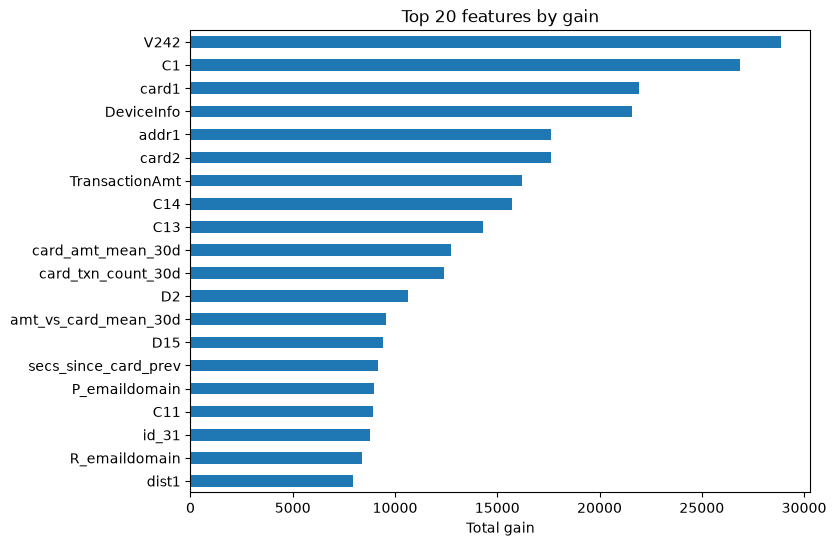

Rank of engineered features (1 = most important):
card_amt_mean_30d       10
card_txn_count_30d      11
amt_vs_card_mean_30d    13
secs_since_card_prev    15
amt_cents               24
hour                    25
email_match             80


In [13]:
# Choose the final configuration by validation Average Precision
lgb_names = list(experiments)
final_name = str(validation_results.loc[lgb_names, 'Average Precision'].idxmax())
final_model = models[final_name]
final_features = experiments[final_name][0]
print(f"Final model: {final_name}")

# Score every row once; reused for evaluation, the threshold and drift monitoring
df['score'] = final_model.predict(df[final_features], num_iteration = final_model.best_iteration).astype('float32')
p_valid, p_test = df['score'].loc[valid.index], df['score'].loc[test.index]

# Which features drive the model?
importance = pd.Series(final_model.feature_importance('gain'), index = final_features).sort_values()
importance.tail(20).plot.barh(figsize = (8, 6))
plt.title('Top 20 features by gain')
plt.xlabel('Total gain')
plt.show()

engineered = ['amt_cents', 'email_match', 'card_txn_count_30d', 'card_amt_mean_30d', 'amt_vs_card_mean_30d',
              'secs_since_card_prev', 'hour', 'if_score']
rank = importance.rank(ascending = False).astype(int)
print("Rank of engineered features (1 = most important):")
print(rank.reindex([f for f in engineered if f in rank.index]).sort_values().to_string())

**Reading the validation results.** *(Draft: review)*
- **LightGBM clearly leads:** validation AP **0.623** (18.4x the base rate), against 0.374 for logistic regression and 0.178 for IsolationForest on its own.
- **`scale_pos_weight` made no difference** (0.622 vs 0.623). AP measures *ranking*, and re-weighting mainly shifts the predicted probabilities rather than the order. So we handle the imbalance where it matters for the business, by choosing the alert threshold by cost (section 10), not by re-weighting.
- **The IsolationForest feature did not help (0.603 vs 0.623).** Part 1 suggested the anomaly score might work as an extra feature. On real data with 280+ informative features, the supervised model already captures what the unsupervised score knows. This is a **negative result, reported honestly**. With a single run per configuration, differences of about ±0.02 could be noise, but there is no evidence of a gain.
- **The engineered card-history features add real signal:** the 30-day card features rank **10th, 11th, 13th and 15th** of 286 features.
- **To check:** the base and `scale_pos_weight` runs stopped close to the 3,000-round cap, so they may improve slightly with more rounds.

### 9. Final evaluation on the test period

The test period (the final ~30 days) has not been used for training, early stopping, model choice or thresholds. Each model is scored on it **once**.

**Bootstrap confidence interval:** we resample the test transactions 500 times and recompute AP, to show how much the headline number could move by chance.

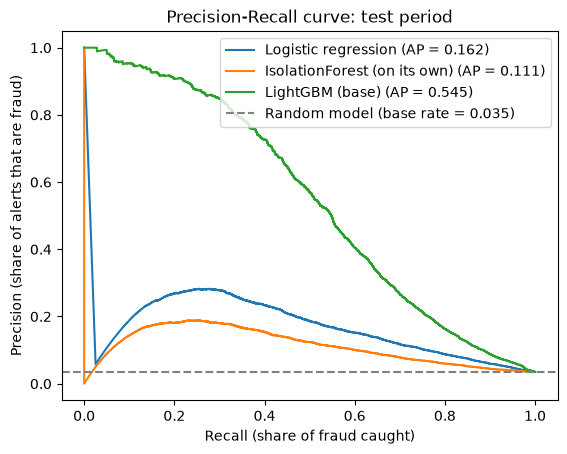

,Average Precision,lift over base rate,ROC-AUC,AP 95% CI
Logistic regression,0.161937,4.645216,0.824882,NaN
IsolationForest (on its own),0.110547,3.171087,0.757424,NaN
LightGBM (base),0.54481,15.628023,0.902099,0.526-0.561


In [14]:
from sklearn.metrics import precision_recall_curve

test_scores = {
    'Logistic regression': logreg.predict_proba(test[numeric_features])[:, 1],
    'IsolationForest (on its own)': df['if_score'].loc[test.index],
    final_name: p_test,
}

test_results = {}
for name, s in test_scores.items():
    ap = average_precision_score(y_test, s)
    test_results[name] = {'Average Precision': ap, 'lift over base rate': ap / y_test.mean(), 'ROC-AUC': roc_auc_score(y_test, s)}

# Bootstrap 95% interval for the final model's AP
rng = np.random.default_rng(RANDOM_STATE)
y_arr, p_arr = y_test.to_numpy(), p_test.to_numpy()
boot = []
for _ in range(500):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    boot.append(average_precision_score(y_arr[idx], p_arr[idx]))
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
test_results[final_name]['AP 95% CI'] = f"{ci_low:.3f}-{ci_high:.3f}"

for name, s in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, s)
    plt.plot(recall, precision, label = f"{name} (AP = {test_results[name]['Average Precision']:.3f})")
plt.axhline(y_test.mean(), color = 'grey', linestyle = '--', label = f'Random model (base rate = {y_test.mean():.3f})')
plt.xlabel('Recall (share of fraud caught)')
plt.ylabel('Precision (share of alerts that are fraud)')
plt.title('Precision-Recall curve: test period')
plt.legend()
plt.show()

pd.DataFrame(test_results).T

**Reading the test results.** *(Draft: review)*
- On the unseen test month, LightGBM scores **AP 0.545 (95% CI 0.526–0.561)**, about **15.6x the 3.5% base rate**. Logistic regression scores 0.162 and IsolationForest 0.111.
- **Precision stays high for the riskiest transactions.** At about 30% recall, roughly 85% of alerts are fraud. Precision falls below 50% only beyond roughly 55% recall. A team with limited capacity can therefore work the top of the list with very few false alerts.
- **Performance drops from validation (0.623) to test (0.545).** Some decline one month further out is expected as fraud patterns change (see section 11). **Logistic regression collapses much more (0.374 → 0.162)**, suggesting the linear model relies on relationships that don't hold a month later, while the tree model degrades more gracefully. *To investigate: which features drive the logistic regression drop (candidates: the `D` time-delta columns, which grow with time).*

**Not comparable with the Kaggle leaderboard:** the competition used a different test set and ranked on ROC-AUC, while we use our own time-based split with AP as the primary metric.

### 10. Cost-based alert threshold

A fraud team doesn't need a probability. It needs to decide **which transactions to send for review**. The right threshold depends on two costs:
- **Missed fraud:** the transaction amount is lost.
- **Reviewing an alert:** analyst time, assumed to be **$5 per alert** (a few minutes of an analyst's time). This is an assumption, so we also show how the answer changes with it.

The threshold is chosen on the **validation** period, then applied unchanged to the test period. The cost curve is usually **flat near its minimum**, so many alert volumes cost almost the same. We therefore pick the **lowest alert volume whose cost is within 1% of the minimum**. This capacity-aware rule saves analyst time at almost no extra cost. Customer friction from false alerts is not costed, so this view is somewhat favourable to flagging more transactions.

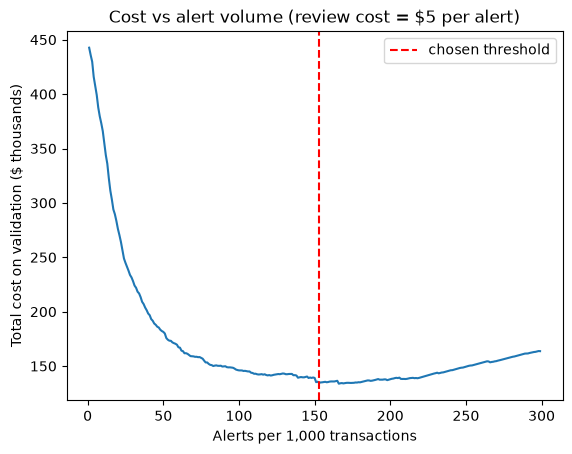

alerts per 1,000 transactions            165.82
precision (alerts that are fraud)          0.17
fraud cases caught (%)                    79.54
fraud value caught ($)               370,161.31
fraud value caught (%)                    77.54
total cost with model ($)            181,254.62
total cost without model ($)         477,355.94
dtype: str

In [15]:
from fraud.costs import best_threshold, outcome

REVIEW_COST = 5.0   # assumed cost of reviewing one alert, in USD
amt_valid = valid['TransactionAmt'].to_numpy()
amt_test = test['TransactionAmt'].to_numpy()


# best_threshold and outcome live in fraud/costs.py (tested in tests/test_costs.py).
# The threshold is chosen on the validation month only.
threshold, alert_rates, costs = best_threshold(y_valid, p_valid, amt_valid, REVIEW_COST)

plt.plot(1000 * alert_rates, costs / 1e3)
plt.axvline(1000 * (p_valid >= threshold).mean(), color = 'red', linestyle = '--', label = 'chosen threshold')
plt.xlabel('Alerts per 1,000 transactions')
plt.ylabel('Total cost on validation ($ thousands)')
plt.title(f'Cost vs alert volume (review cost = ${REVIEW_COST:.0f} per alert)')
plt.legend()
plt.show()

test_outcome = pd.Series(outcome(threshold, y_test, p_test, amt_test, REVIEW_COST))
test_outcome.map(lambda v: f"{v:,.2f}")

In [16]:
# Sensitivity: how does the operating point change with the assumed review cost?
sensitivity = {}
for cost in [1, 5, 10, 25, 50]:
    t, _, _ = best_threshold(y_valid, p_valid, amt_valid, cost)
    o = outcome(t, y_test, p_test, amt_test, cost)
    sensitivity[f'${cost} per alert'] = {
        'alerts per 1,000': o['alerts per 1,000 transactions'],
        'precision': o['precision (alerts that are fraud)'],
        'fraud value caught (%)': o['fraud value caught (%)'],
        'cost saved vs no model (%)': 100 * (1 - o['total cost with model ($)'] / o['total cost without model ($)']),
    }
pd.DataFrame(sensitivity).T.round(2)

,"alerts per 1,000",precision,fraud value caught (%),cost saved vs no model (%)
$1 per alert,283.20,0.11,87.37,82.07
$5 per alert,165.82,0.17,77.54,62.03
$10 per alert,87.57,0.28,65.26,48.88
$25 per alert,44.22,0.45,50.65,29.97
$50 per alert,25.57,0.63,37.17,13.25


**Reading the cost analysis.** *(Draft: review)*

**Headline:** on the unseen test month, at a $5 review cost, the model catches **$370,161 of $477,356 fraud value (77.5%)** at **166 alerts per 1,000 transactions (about 478 alerts a day)**. 16.7% of alerts are fraud. After paying for reviews, that is a **net saving of $296,101, or 62% of fraud losses**, compared with no model.

- **Review cost drives the operating point.** At $1 per alert the best policy is to review 28% of transactions. At $50 it falls to 2.6%, with 63% of alerts being fraud. The cheaper a review, the more alerts are worth working.
- **Capacity matters.** About 478 alerts a day may exceed a real team's capacity. The dashboard lets you set the alert volume directly, and the cost curve is flat near its minimum, so lower volumes cost little extra.
- **What's not costed:** customer friction from false alerts (declined or delayed genuine purchases), and fraud that is caught but still partly lost. Both would push the optimal alert volume down.

### 11. Drift monitoring

**Population Stability Index (PSI)** measures how much a variable's distribution has shifted from a reference period. Here the reference is the **training window**. Each variable is split into 10 bins using the training distribution (missing values get their own bin), and the PSI is

$$\text{PSI} = \sum_{\text{bins}} (a - e)\,\ln\frac{a}{e}$$

where *e* and *a* are the shares of rows in each bin for the reference and the monitored period. Rule of thumb: **< 0.1 stable, 0.1–0.25 moderate shift, > 0.25 significant shift.**

**Why label-free monitoring matters: label delay.** In production, fraud labels arrive late. A transaction is usually only confirmed as fraud when the cardholder disputes it and a chargeback is filed, often weeks later. So live Average Precision can't be measured in real time. PSI on the **model score** and on the **key input features** needs no labels, so it is the early-warning signal. AP per period is the lagging confirmation once the labels arrive.

In [17]:
from fraud.monitoring import psi  # tested in tests/test_monitoring.py

monitored = ['score', *importance.sort_values(ascending = False).index[:10].tolist()]
reference = df.loc[train.index]

psi_table = pd.DataFrame({
    p: {col: psi(reference[col], df[col][df['period'] == p]) for col in monitored}
    for p in sorted(df['period'].unique())
})
psi_table.columns = [f'period {p}' for p in psi_table.columns]

psi_table.style.format('{:.3f}').background_gradient(cmap = 'Reds', vmin = 0, vmax = 0.25)

,period 0,period 1,period 2,period 3,period 4,period 5
score,0.015,0.004,0.002,0.006,0.003,0.009
V242,0.124,0.034,0.032,0.036,0.049,0.026
C1,0.018,0.004,0.007,0.002,0.009,0.014
card1,0.001,0.001,0.000,0.001,0.001,0.004
DeviceInfo,0.152,0.047,0.055,0.069,0.080,0.049
addr1,0.003,0.001,0.001,0.002,0.002,0.004
card2,0.011,0.004,0.002,0.005,0.009,0.006
TransactionAmt,0.046,0.010,0.010,0.013,0.010,0.010
C14,0.018,0.004,0.006,0.002,0.009,0.011
C13,0.039,0.010,0.013,0.004,0.032,0.025


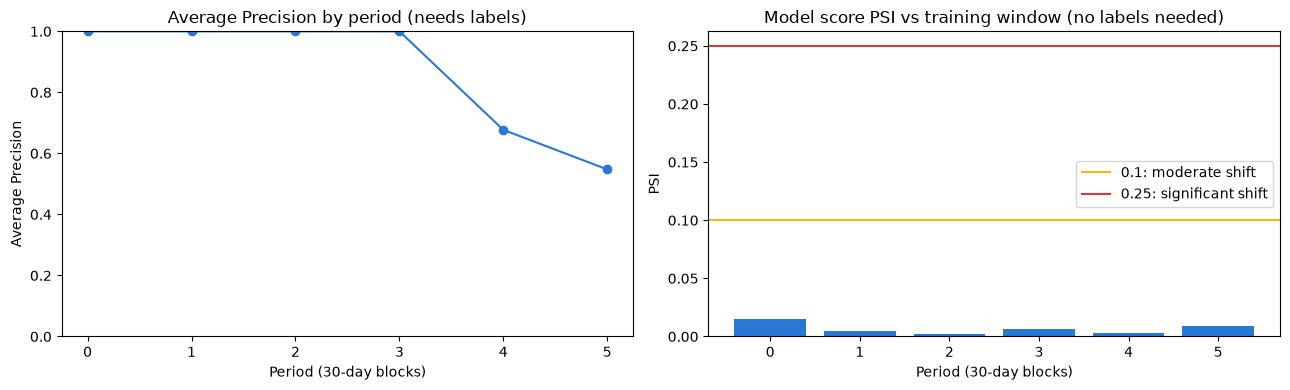

,fraud rate,Average Precision,score PSI,lift,used for
period,,,,,
0,0.025,1.000,0.015,40.385,train
1,0.040,1.000,0.004,24.769,train
2,0.040,1.000,0.002,24.802,train
3,0.039,1.000,0.006,25.468,train
4,0.035,0.677,0.003,19.501,validation
5,0.035,0.548,0.009,15.790,test


In [18]:
# Lagging check once labels arrive: AP per period, and how far each period's fraud rate is from the base rate
period_perf = pd.DataFrame({
    p: {
        'fraud rate': d[TARGET].mean(),
        'Average Precision': average_precision_score(d[TARGET], d['score']),
        'score PSI': psi(reference['score'], d['score']),
    }
    for p, d in df.groupby('period')
}).T.rename_axis('period')
period_perf['lift'] = period_perf['Average Precision'] / period_perf['fraud rate']
period_perf['used for'] = ['train' if d < valid_start else ('validation' if d < test_start else 'test')
                           for d in df.groupby('period')['day'].max()]

# Two separate charts rather than one dual-axis chart, so the scales can't suggest a false correlation
fig, axes = plt.subplots(1, 2, figsize = (13, 4))
axes[0].plot(period_perf.index, period_perf['Average Precision'], marker = 'o', color = '#2a78d6')
axes[0].set(title = 'Average Precision by period (needs labels)', xlabel = 'Period (30-day blocks)', ylabel = 'Average Precision', ylim = (0, 1))
axes[1].bar(period_perf.index, period_perf['score PSI'], color = '#2a78d6')
axes[1].axhline(0.1, color = '#fab219', label = '0.1: moderate shift')
axes[1].axhline(0.25, color = '#d03b3b', label = '0.25: significant shift')
axes[1].set(title = 'Model score PSI vs training window (no labels needed)', xlabel = 'Period (30-day blocks)', ylabel = 'PSI')
axes[1].legend()
plt.tight_layout()
plt.show()

period_perf.round(3)

**Reading the drift results.** *(Draft: review)*
- **The model score is stable:** PSI stays below 0.02 in every period, well under the 0.1 "moderate" level.
- **The 30-day card features fixed an earlier drift problem.** A first version used cumulative "all history" features, and `card_amt_mean_prior` reached **PSI ≈ 0.30–0.33** (significant shift) in the validation and test months. The 30-day version stays at about 0.02. **Monitoring caught a design flaw in our own features.**
- **Period 0 differs most** (e.g. `DeviceInfo` 0.15, `V242` 0.12). It is also the period with the lowest fraud rate (2.5% vs ~3.5–4%). It may reflect a seasonal or holiday mix, or a change in data capture.
- **Key lesson: score PSI did not catch the performance drop.** AP falls from 0.68 (validation period) to 0.55 (test period) while score PSI stays near zero. PSI detects changes in *who* is transacting (data drift), not changes in *how fraud behaves* (concept drift). Label-free PSI is an early warning, not a guarantee, so it must be paired with AP once chargeback labels arrive.
- Training periods (0–3) show AP = 1.0 because the model has seen them: in-sample, not a real result.

**In production:** compute score PSI daily or weekly with no labels needed, and alert at PSI > 0.1. Confirm with AP once chargeback labels mature, then retrain on a rolling window when either signal degrades.

### 12. Business impact summary

Answering the business question for the unseen test month at the recommended operating point ($5 review cost, threshold chosen on validation). The **per million transactions** figure scales the test month linearly and is illustrative: it assumes the same fraud rate and amount mix.

In [19]:
test_days = test['day'].nunique()
o = outcome(threshold, y_test, p_test, amt_test, REVIEW_COST)
n_alerts = (p_test >= threshold).sum()
saving = o['total cost without model ($)'] - o['total cost with model ($)']

impact = pd.Series({
    'test period': f"{test_days} days, {len(test):,} transactions, {int(y_test.sum()):,} frauds",
    'fraud value in period': f"${o['total cost without model ($)']:,.0f}",
    'fraud value caught': f"${o['fraud value caught ($)']:,.0f} ({o['fraud value caught (%)']:.1f}%)",
    'alerts per day (analyst workload)': f"{n_alerts / test_days:,.0f}",
    'alerts per 1,000 transactions': f"{o['alerts per 1,000 transactions']:.1f}",
    'alert precision': f"{o['precision (alerts that are fraud)']:.1%}",
    'review cost': f"${REVIEW_COST * n_alerts:,.0f}",
    'net saving vs no model': f"${saving:,.0f} ({100 * saving / o['total cost without model ($)']:.1f}% of fraud losses)",
    'net saving per million transactions (illustrative)': f"${saving / len(test) * 1e6:,.0f}",
})
impact.to_frame('value')

,value
test period,"31 days, 89,326 transactions, 3,114 frauds"
fraud value in period,"$477,356"
fraud value caught,"$370,161 (77.5%)"
alerts per day (analyst workload),478
"alerts per 1,000 transactions",165.8
alert precision,16.7%
review cost,"$74,060"
net saving vs no model,"$296,101 (62.0% of fraud losses)"
net saving per million transactions (illustrative),"$3,314,839"


### 13. Export results for the dashboard

The Streamlit dashboard (`dashboard/app.py`) reads one JSON file of **aggregated results**: cost and capture at each alert level, metric tables, drift and feature importance. **No row-level transaction data is exported**, in line with the competition's data-sharing rules, so the dashboard can be published safely.

In [20]:
from pathlib import Path

from sklearn.metrics import precision_recall_curve

DASHBOARD_DATA = Path('dashboard') / 'data'
DASHBOARD_DATA.mkdir(parents = True, exist_ok = True)

# Capture curve on the test month: what happens at each alert volume
yt, pt = y_test.to_numpy(), p_test.to_numpy()
curve = []
for rate in np.round(np.arange(0.001, 0.301, 0.001), 3):
    t = np.quantile(pt, 1 - rate)
    alert = pt >= t
    curve.append({
        'alerts_per_1000': 1000 * alert.mean(),
        'alerts': int(alert.sum()),
        'frauds_caught': int((alert & (yt == 1)).sum()),
        'fraud_value_caught': float(amt_test[alert & (yt == 1)].sum()),
    })

# Recommended operating point for each review cost (threshold chosen on validation, applied to test)
recommended = {}
for cost in range(1, 51):
    t, _, _ = best_threshold(y_valid, p_valid, amt_valid, cost)
    alert = pt >= t
    recommended[cost] = {
        'alerts_per_1000': 1000 * alert.mean(),
        'alerts': int(alert.sum()),
        'frauds_caught': int((alert & (yt == 1)).sum()),
        'fraud_value_caught': float(amt_test[alert & (yt == 1)].sum()),
    }

# Precision-recall curves on test, thinned to ~200 points each
pr_curves = {}
for name, s in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, s)
    keep = np.unique(np.linspace(0, len(recall) - 1, 200).astype(int))
    pr_curves[name] = {'recall': recall[keep].round(4).tolist(), 'precision': precision[keep].round(4).tolist()}


def table(frame):
    return {row: {k: (v if isinstance(v, str) else float(v)) for k, v in vals.items()} for row, vals in frame.items()}


export = {
    'totals': {
        'test_days': int(test_days),
        'test_transactions': len(test),
        'test_frauds': int(y_test.sum()),
        'test_fraud_value': float(amt_test[yt == 1].sum()),
        'test_fraud_rate': float(y_test.mean()),
    },
    'final_model': final_name,
    'capture_curve': curve,
    'recommended': recommended,
    'validation_results': table(validation_results.drop(columns = 'best iteration').T.to_dict()),
    'test_results': table(pd.DataFrame(test_results).T.drop(columns = 'AP 95% CI', errors = 'ignore').T.to_dict()),
    'test_ap_ci': test_results[final_name]['AP 95% CI'],
    'pr_curves': pr_curves,
    'feature_importance': importance.sort_values(ascending = False).head(15).round(1).to_dict(),
    'psi': {col: {k: float(v) for k, v in row.items()} for col, row in psi_table.T.to_dict().items()},
    'period_performance': {int(p): {k: (v if isinstance(v, str) else float(v)) for k, v in row.items()}
                           for p, row in zip(period_perf.index.astype(int), period_perf.to_dict('records'))},
    'memory_report': {k: float(v) for k, v in memory_report.items()},
}
(DASHBOARD_DATA / 'results.json').write_text(json.dumps(export, indent = 1))
print(f"Wrote {DASHBOARD_DATA / 'results.json'} ({(DASHBOARD_DATA / 'results.json').stat().st_size / 1e3:.0f} KB)")

Wrote dashboard\data\results.json (71 KB)


## Conclusion *(Draft: review)*

**Business answer.** A LightGBM model trained on four months of real e-commerce transactions, with its alert threshold set by cost, would have caught **77.5% of fraud value ($370k)** in an unseen month, for a **net saving of $296k (62% of fraud losses)** after review costs, at about 478 alerts a day. At higher review costs the team can work far fewer, higher-precision alerts (63% precision at $50 per alert).

### Results (test month, unseen)

| Model | Average Precision | Lift over base rate | ROC-AUC |
|---|---|---|---|
| **LightGBM** | **0.545** (95% CI 0.526–0.561) | **15.6x** | 0.902 |
| Logistic regression | 0.162 | 4.6x | 0.825 |
| IsolationForest (on its own) | 0.111 | 3.2x | 0.757 |

### Key findings
1. **Supervised beats unsupervised by a wide margin on real data** (AP 0.545 vs 0.111), confirming Part 1's main conclusion.
2. **Part 1's secondary idea, the anomaly score as an extra feature, did not hold up:** it didn't improve LightGBM. A useful negative result.
3. **The alert threshold is a business decision, not a modelling one.** The best alert volume ranges from 26 to 283 per 1,000 transactions, depending on review cost.
4. **Monitoring found a real problem:** cumulative per-card features drifted significantly (PSI ≈ 0.3), and were replaced with 30-day windows.
5. **Score PSI is necessary but not sufficient:** it stayed stable while AP fell from validation to test, so label-based checks are still needed once chargebacks arrive.

### Limitations
- Many columns are anonymised (`C`, `D`, `M`, `V`, `id_`), which limits interpretation.
- About 6 months of data from one e-commerce merchant, not a bank.
- Labels come from chargebacks, so some fraud is probably labelled as normal.
- The review cost is an assumption, and customer friction from false alerts is not costed.
- The card key is approximate: different cards can share a key, and one card can appear under more than one key.
- One training run per configuration, so small differences between configurations may be noise.

### Next steps
- **Production simulation:** score Kaggle's unlabelled later months and run label-free monitoring on them.
- Investigate the logistic regression collapse and the validation-to-test AP drop (concept drift).
- Retrain on a rolling window and measure whether recent data recovers performance.
- Add customer-friction cost and a capacity limit to the threshold choice.
